In [19]:
import folium as fl
import geopandas as gpd
import geodatasets
import contextily as cx
import matplotlib.pyplot as plt
from gee_image_search_download import (GEEClient, ImageCollectionCatalog, ImageFinder)

In [20]:
client = GEEClient(project=None).connect()

In [21]:
catalog = ImageCollectionCatalog.default()

In [22]:
aoi_path = f"/home/cusicand/03_Data/GMC_REPOSITORY/LandslideOggigins.gpkg"
my_aoi_gdf = gpd.read_file(aoi_path)

<Axes: >

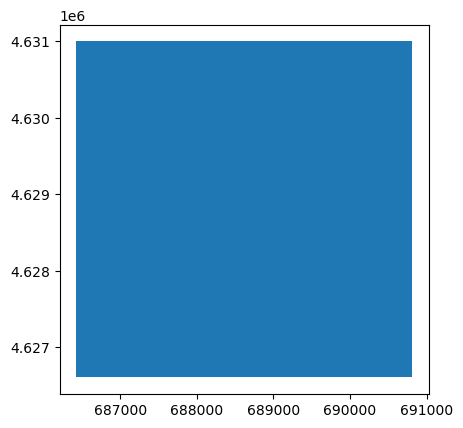

In [23]:
my_aoi_gdf.plot()

In [29]:
finder = ImageFinder(client, catalog, aoi=my_aoi_gdf, year_range=(2015, 2025), month_range=(10, 11), cloud_max=20)

In [30]:
images = finder.search_metadata()

In [32]:
len(images)

58

In [33]:
images

,image_id,collection_key,collection_name,acquisition_date,cloud_percent,nominal_scale_m,footprint_area_m2,footprint_area_km2,aoi_coverage_percent,overlap_ratio,geometry
0,LC08_230094_20241014,L8_SR,Landsat 8 SR (C2 L2),2024-10-14,18.700000,30,3.696590e+10,36965.903824,38.653845,0.000201,"POLYGON ((-70.38236 -49.92497, -70.33951 -49.9..."
1,LC08_230094_20241014,L8_TOA,Landsat 8 TOA (C2 L1),2024-10-14,18.700000,15,3.784334e+10,37843.341141,84.121603,0.000427,"POLYGON ((-72.90232 -49.47872, -72.84782 -49.4..."
2,LC09_230094_20231105,L9_SR,Landsat 9 SR (C2 L2),2023-11-05,8.300000,30,3.707840e+10,37078.404189,2.563620,0.000013,"POLYGON ((-69.66098 -48.23486, -69.66168 -48.2..."
3,LC09_230094_20231105,L9_TOA,Landsat 9 TOA (C2 L1),2023-11-05,8.300000,15,3.783496e+10,37834.956398,50.418292,0.000256,"POLYGON ((-72.16083 -47.79271, -72.16179 -47.7..."
4,20231101T142711_20231101T144014_T18FXM,S2_SR,Sentinel‑2 SR (harmonized),2023-11-01,5.025565,10,1.202219e+10,12022.193820,100.000000,0.001598,"POLYGON ((-73.63736 -48.83285, -73.63734 -48.8..."
5,LC09_230094_20231020,L9_SR,Landsat 9 SR (C2 L2),2023-10-20,3.940000,30,3.707580e+10,37075.798755,59.727776,0.000310,"POLYGON ((-72.8923 -49.48487, -72.80214 -49.50..."
6,LC09_230094_20231020,L9_TOA,Landsat 9 TOA (C2 L1),2023-10-20,3.940000,15,3.782978e+10,37829.779020,99.879830,0.000507,"POLYGON ((-70.32237 -49.93613, -70.31981 -49.9..."
7,LC09_230094_20231004,L9_SR,Landsat 9 SR (C2 L2),2023-10-04,5.340000,30,3.708255e+10,37082.546483,27.802063,0.000144,"POLYGON ((-72.84578 -49.40423, -72.87341 -49.4..."
8,LC09_230094_20231004,L9_TOA,Landsat 9 TOA (C2 L1),2023-10-04,5.340000,15,3.783796e+10,37837.958504,81.352396,0.000413,"POLYGON ((-69.65769 -48.23879, -69.6587 -48.23..."
9,LC08_230094_20221126,L8_SR,Landsat 8 SR (C2 L2),2022-11-26,10.740000,30,3.695593e+10,36955.933728,2.293545,0.000012,"POLYGON ((-72.57033 -48.8211, -72.6004 -48.890..."


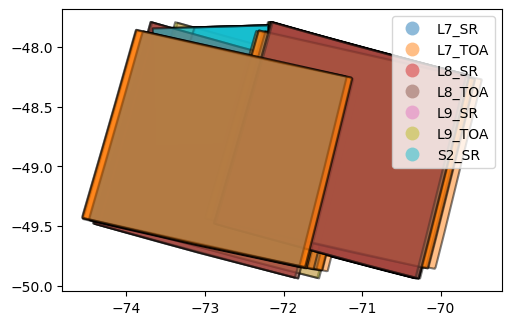

In [34]:
fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)

images.plot(
    ax=ax,
    column='collection_key',
    linewidth=1.5,
    legend=True,
    edgecolor='black',
    alpha=0.5
)
# my_aoi_gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)
plt.show()

In [39]:
keys = ["L8_TOA", "L9_TOA"]
images_filter = images.loc[(images['aoi_coverage_percent'] > 80) & (images['collection_key'].isin(keys))]

In [41]:
images_filter

,image_id,collection_key,collection_name,acquisition_date,cloud_percent,nominal_scale_m,footprint_area_m2,footprint_area_km2,aoi_coverage_percent,overlap_ratio,geometry
1,LC08_230094_20241014,L8_TOA,Landsat 8 TOA (C2 L1),2024-10-14,18.70,15,3.784334e+10,37843.341141,84.121603,0.000427,"POLYGON ((-72.90232 -49.47872, -72.84782 -49.4..."
6,LC09_230094_20231020,L9_TOA,Landsat 9 TOA (C2 L1),2023-10-20,3.94,15,3.782978e+10,37829.779020,99.879830,0.000507,"POLYGON ((-70.32237 -49.93613, -70.31981 -49.9..."
8,LC09_230094_20231004,L9_TOA,Landsat 9 TOA (C2 L1),2023-10-04,5.34,15,3.783796e+10,37837.958504,81.352396,0.000413,"POLYGON ((-69.65769 -48.23879, -69.6587 -48.23..."
14,LC09_230094_20221017,L9_TOA,Landsat 9 TOA (C2 L1),2022-10-17,9.61,15,3.782811e+10,37828.108223,91.314065,0.000464,"POLYGON ((-69.6654 -48.23774, -69.66693 -48.23..."
17,LC08_231094_20221016,L8_TOA,Landsat 8 TOA (C2 L1),2022-10-16,3.90,15,3.784752e+10,37847.519424,100.000000,0.000508,"POLYGON ((-73.12163 -47.89779, -73.55679 -47.8..."
21,LC09_231094_20211109,L9_TOA,Landsat 9 TOA (C2 L1),2021-11-09,2.02,15,3.737899e+10,37378.986541,100.000000,0.000514,"POLYGON ((-74.08622 -49.4303, -74.11103 -49.48..."
33,LC08_231094_20191109,L8_TOA,Landsat 8 TOA (C2 L1),2019-11-09,5.81,15,3.784270e+10,37842.698285,100.000000,0.000508,"POLYGON ((-71.17169 -48.24911, -71.16821 -48.2..."


<Axes: >

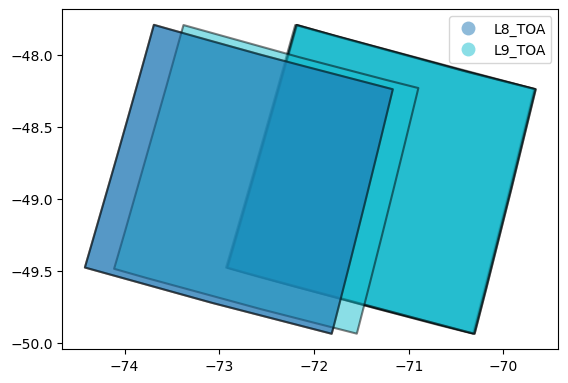

In [42]:
images_filter.plot(column='collection_key',
    linewidth=1.5,
    legend=True,
    edgecolor='black',
    alpha=0.5)

In [43]:
len(images_filter)

7

In [44]:
finder.bulk_download(images_filter, output_dir="/home/cusicand/03_Data/GMC_REPOSITORY/", region_mode="aoi")

Downloading:   0%|          | 0/7 [00:00<?, ?img/s]

Generating URL ...
Please wait ...


Downloading:  14%|█▍        | 1/7 [00:01<00:11,  1.84s/img]

Data downloaded to /home/cusicand/03_Data/GMC_REPOSITORY/L8_TOA/L8_TOA_20241014_15m.tif
Generating URL ...
Please wait ...


Downloading:  29%|██▊       | 2/7 [00:03<00:09,  2.00s/img]

...

Downloading:  86%|████████▌ | 6/7 [00:10<00:01,  1.56s/img]

Data downloaded to /home/cusicand/03_Data/GMC_REPOSITORY/L9_TOA/L9_TOA_20211109_15m.tif
Generating URL ...
Please wait ...


Downloading: 100%|██████████| 7/7 [00:11<00:00,  1.71s/img]

Data downloaded to /home/cusicand/03_Data/GMC_REPOSITORY/L8_TOA/L8_TOA_20191109_15m.tif


[PosixPath('/home/cusicand/03_Data/GMC_REPOSITORY/L8_TOA/L8_TOA_20241014_15m.tif'),
 PosixPath('/home/cusicand/03_Data/GMC_REPOSITORY/L9_TOA/L9_TOA_20231020_15m.tif'),
 PosixPath('/home/cusicand/03_Data/GMC_REPOSITORY/L9_TOA/L9_TOA_20231004_15m.tif'),
 PosixPath('/home/cusicand/03_Data/GMC_REPOSITORY/L9_TOA/L9_TOA_20221017_15m.tif'),
 PosixPath('/home/cusicand/03_Data/GMC_REPOSITORY/L8_TOA/L8_TOA_20221016_15m.tif'),
 PosixPath('/home/cusicand/03_Data/GMC_REPOSITORY/L9_TOA/L9_TOA_20211109_15m.tif'),
 PosixPath('/home/cusicand/03_Data/GMC_REPOSITORY/L8_TOA/L8_TOA_20191109_15m.tif')]